In [1]:
import pandas as pd
import matplotlib.pyplot as plt


#Read the CSV from the data folder
df = pd.read_csv("../data/final/Team6_PyForce_cleaned_data.csv")

print("Dataset shape:", df.shape)
print("Total patients:", len(df))


Dataset shape: (2008, 171)
Total patients: 2008


**Q1: Which patients with the most severe cardiac conditions should be prioritized for closer monitoring?**

**Reason:**
We first want to identify patients with more severe heart conditions. In the dataset, NYHA class can be used to separate severity groups. We compare the number of patients and their 6-month readmission and mortality rates. If the more severe groups also show poorer outcomes, they may deserve higher monitoring priority.



,Patients,Readmission_6M,Mortality_6M
nyha_class,,,
2,353,29.178470,2.549575
3,1039,38.017324,1.732435
4,616,44.642857,4.870130


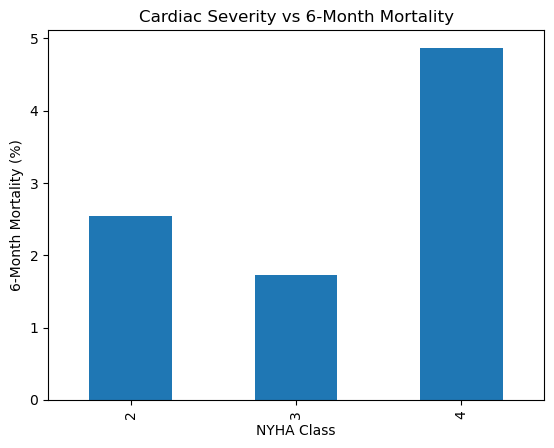

In [2]:
severity = df.groupby("nyha_class").agg(
    Patients=("patient_id", "count"),
    Readmission_6M=("re_admission_within_6_months", "mean"),
    Mortality_6M=("death_within_6_months", "mean")
)
severity[["Readmission_6M", "Mortality_6M"]] *= 100
display(severity)

severity["Mortality_6M"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.xlabel("NYHA Class")
plt.title("Cardiac Severity vs 6-Month Mortality")
plt.show()


**Analysis:**
As per the analysis, Class 4 patients suffer from the worst rates of both readmission and death. Since they represent the highest-risk group in the chronic heart failure, they should be prioritized for Close Monitoring. Also Hospital management should taking necessary measure: 1.Provide mandatory check-in to avoid worst outcome considering patient health as it will also helps in suppressing re-admission rate 2. Staff management to be taken care to provide necessary services considering Class-4 patients readmission rate

**Q2. Which Killip Grade patients should receive the highest monitoring priority?**

Reason:
Killip grade provides another way to describe cardiac severity. We compare patient counts and mortality across grades. A grade with a noticeably higher mortality rate can be considered an important group for further review.



,Patients,Mortality
killip_grade,,
1,527,0.759013
2,1029,1.554908
3,392,5.357143
4,60,26.666667


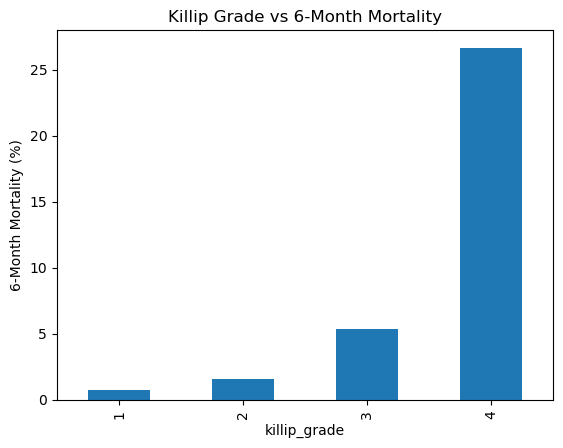

In [3]:
result = df.groupby("killip_grade").agg(
    Patients=("patient_id", "count"),
    Mortality=("death_within_6_months", "mean")
)
result["Mortality"] *= 100
display(result)

result["Mortality"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.title("Killip Grade vs 6-Month Mortality")
plt.show()


**Analysis:**
This shows that Killip Grade 4 has hightest mortality rate where more than 1 in 4 patients do not survive, making it a clear indicator for intensive care 

**Q3. Which patients with low responsiveness should receive closer monitoring?**

Reason: Most patients may be alert, while a smaller group may respond only to sound or pain or may be nonresponsive. Comparing responsiveness groups with mortality helps us understand whether reduced responsiveness is associated with poorer outcomes.


,Patients,Mortality_6M
consciousness,,
Clear,1974,2.127660
Nonresponsive,11,100.000000
ResponsiveToPain,4,25.000000
ResponsiveToSound,19,15.789474


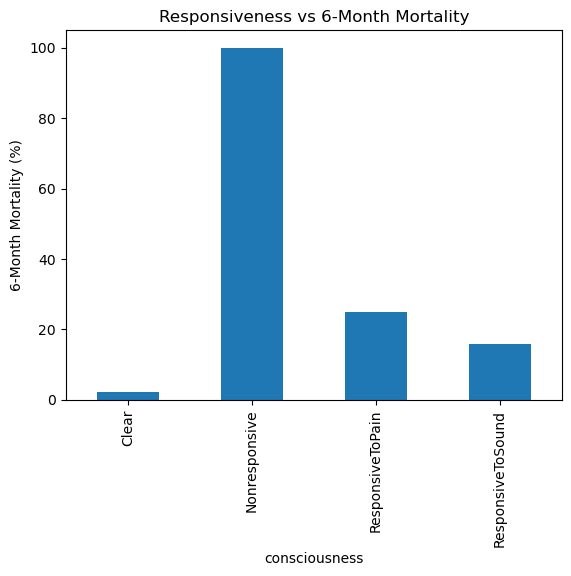

In [4]:
response = df.groupby("consciousness").agg(
    Patients=("patient_id", "count"),
    Mortality_6M=("death_within_6_months", "mean")
)
response["Mortality_6M"] *= 100
display(response)

response["Mortality_6M"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.title("Responsiveness vs 6-Month Mortality")
plt.show()


**Analysis:**
As consciousness decreases, mortality increases sharply.
Clear: 2%,
Responsive to sound:15%,
Responsive to Pain:25%,
Nonresponsive: 100%

Hence Patients who are Non-responsive may require urgent intervention, continuous monitoring, and likely ICU‑level care.
Responsive to Pain/Sound may require enhanced monitoring, frequent reassessment, and early escalation.


**Q4. Which patients have both severe cardiac conditions and poor responsiveness?**

Reason: Severity and responsiveness may be more informative when used together. A patient who has both a severe cardiac condition and reduced responsiveness may represent a higher-priority group than a patient with only one of these characteristics.


Patients in combined group: 38
6-month mortality (%): 42.10526315789473


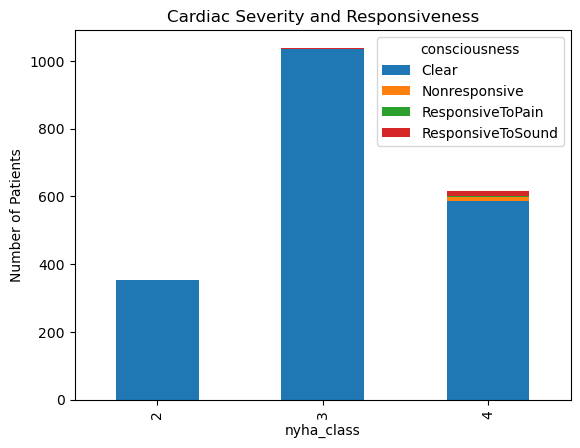

In [5]:
high_priority = df[
    (df["nyha_class"] == 4) &
    (df["glasgow_coma_scale"] < 15)
]

print("Patients in combined group:", len(high_priority))
print("6-month mortality (%):",
      high_priority["death_within_6_months"].mean() * 100)

pd.crosstab(df["nyha_class"], df["consciousness"]).plot(
    kind="bar", stacked=True
)
plt.ylabel("Number of Patients")
plt.title("Cardiac Severity and Responsiveness")
plt.show()


**Analysis:**
Patients who have both severe heart failure (NYHA Class 4) and poor responsiveness have an extremely high death rate of 42.1% (affecting 38 patients in the dataset). This means that when a patient has both a failing heart and decreased consciousness at the same time, their risk multiplies, making them an immediate priority for intensive care or palliative team review


**Q5. Which patients with multiple comorbidities should receive closer follow-up?**

**Reason**
Cardiac patients may also have diabetes, kidney disease, COPD, or other illnesses. CCI score summarizes comorbidity burden. We compare CCI score with readmission and mortality to see whether patients with more health problems have poorer outcomes.


,Patients,Readmission,Mortality
cci_score,,,
0.0,56,44.642857,10.714286
1.0,770,34.935065,1.948052
2.0,699,37.339056,2.718169
3.0,368,42.119565,2.717391
4.0,94,54.255319,6.382979
5.0,15,60.000000,6.666667
6.0,1,100.000000,0.000000


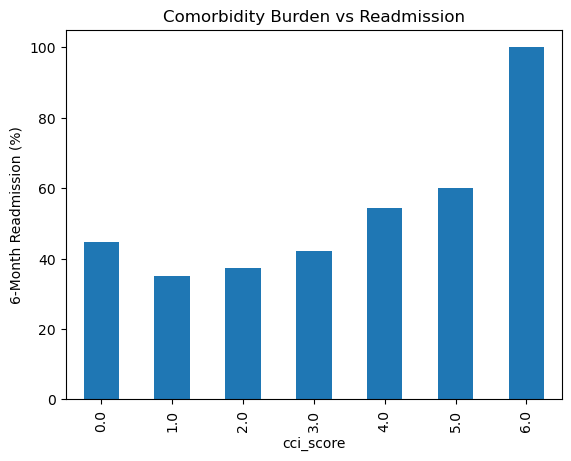

In [6]:
result = df.groupby("cci_score").agg(
    Patients=("patient_id", "count"),
    Readmission=("re_admission_within_6_months", "mean"),
    Mortality=("death_within_6_months", "mean")
)
result[["Readmission", "Mortality"]] *= 100
display(result)

result["Readmission"].plot(kind="bar")
plt.ylabel("6-Month Readmission (%)")
plt.title("Comorbidity Burden vs Readmission")
plt.show()


**Analysis:**
Patients with a higher comorbidity burden tend to have more complex healthcare needs. Identifying these patients allows hospitals to prioritize follow-up care, improve care coordination, and better allocate healthcare resources.


**Q6. Which diabetic cardiac patients should receive additional follow-up?**

**Reason:**
Diabetes is an important comorbidity in cardiac patients. We compare patients with and without diabetes to see whether their readmission and mortality outcomes differ.


,Patients,Readmission,Mortality
diabetes,,,
0,1542,36.316472,2.853437
1,466,45.708155,2.789700


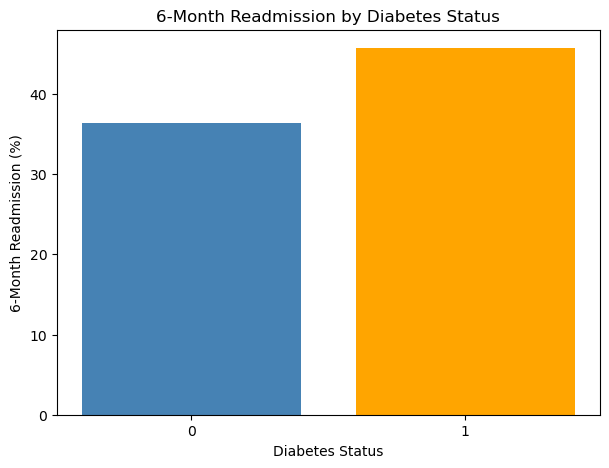

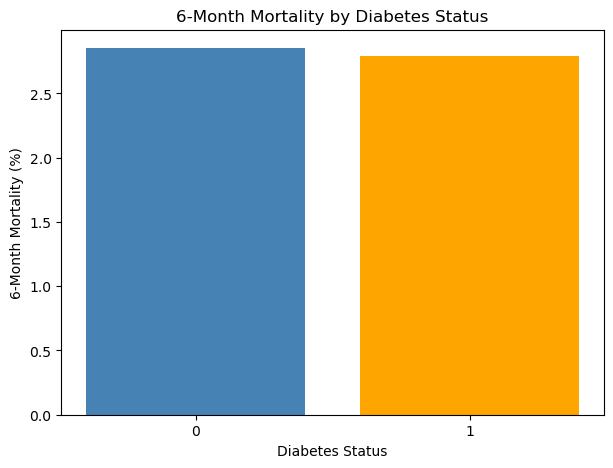

In [7]:
# Compare diabetic and non-diabetic cardiac patients

result = (
    df.groupby("diabetes")
      .agg(
          Patients=("patient_id", "count"),
          Readmission=("re_admission_within_6_months", "mean"),
          Mortality=("death_within_6_months", "mean")
      )
)

# Convert to percentages
result["Readmission"] *= 100
result["Mortality"] *= 100

display(result)

plt.figure(figsize=(7,5))

plt.bar(
    result.index.astype(str),
    result["Readmission"],
    color=["steelblue","orange"]
)

plt.xlabel("Diabetes Status")
plt.ylabel("6-Month Readmission (%)")
plt.title("6-Month Readmission by Diabetes Status")

plt.show()

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["diabetes"],
    df["re_admission_within_6_months"]
)

plt.figure(figsize=(7,5))

plt.bar(
    result.index.astype(str),
    result["Mortality"],
    color=["steelblue","orange"]
)

plt.xlabel("Diabetes Status")
plt.ylabel("6-Month Mortality (%)")
plt.title("6-Month Mortality by Diabetes Status")

plt.show()

**Analysis:**
The charts compare 6-month readmission and 6-month mortality between diabetic and non-diabetic cardiac patients.
If diabetic patients have higher percentages, diabetes may be an important characteristic to consider when identifying patients who could benefit from additional follow-up after discharge.

**Q7. Which cardiac patients with kidney disease should receive closer follow-up?**

**Reason:**
Heart and kidney problems together can make patient care more complex. We compare cardiac patients with and without moderate-to-severe chronic kidney disease and examine their readmission and mortality.



,Patients,Readmission,Mortality
moderate_to_severe_chronic_kidney_disease,,,
0.0,1532,36.161880,2.154047
1.0,474,46.202532,5.063291


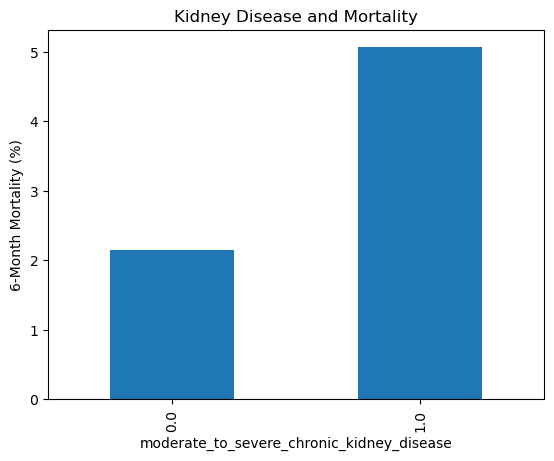

In [8]:
result = df.groupby(
    "moderate_to_severe_chronic_kidney_disease"
).agg(
    Patients=("patient_id", "count"),
    Readmission=("re_admission_within_6_months", "mean"),
    Mortality=("death_within_6_months", "mean")
)
result[["Readmission", "Mortality"]] *= 100
display(result)

result["Mortality"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.title("Kidney Disease and Mortality")
plt.show()


**Analysis**
If kidney-disease patients show poorer outcomes, this group may be a reasonable candidate for closer follow-up and coordinated care.


**Q8. How should discharge and tracking strategies be structured for patients diagnosed with COPD given their uniform readmission risk??**

**Reason:**
COPD affects breathing and may make cardiac care more complicated. We compare patients with and without COPD to see whether readmission differs between the groups.


chronic_obstructive_pulmonary_disease
0    38.535211
1    38.197425
Name: re_admission_within_6_months, dtype: float64

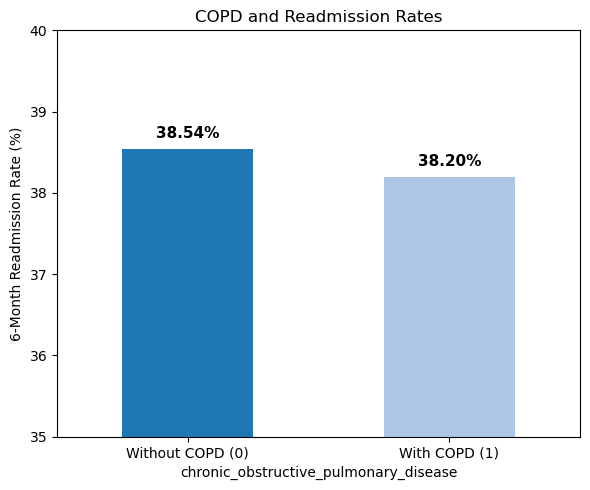

In [9]:
# Calculate the result
result = (
    df.groupby("chronic_obstructive_pulmonary_disease")[
        "re_admission_within_6_months"
    ].mean()
    * 100
)

display(result)

# Create the bar chart
plt.figure(figsize=(6, 5))
bars = result.plot(kind="bar", color=["#1f77b4", "#aec7e8"], width=0.5)

# Set Y-axis limits to zoom in and make the subtle difference clear
plt.ylim(35, 40)
plt.ylabel("6-Month Readmission Rate (%)")
plt.title("COPD and Readmission Rates")

# Add exact data labels on top of each bar
for bar in bars.patches:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.,
      height + 0.1,
      f"{height:.2f}%",
      ha="center",
      va="bottom",
      fontsize=11,
      fontweight="bold",
  )

plt.xticks(
    ticks=[0, 1], labels=["Without COPD (0)", "With COPD (1)"], rotation=0
)
plt.tight_layout()
plt.show()

**Analysis:**
Cardiac patients with and without COPD show nearly identical 6-month readmission rates (38.20% vs. 38.54%). However, targeted monitoring remains essential for patients with COPD due to overlapping symptoms that complicate post-discharge recovery

**Q9. What secondary indicators help pinpoint high-BNP patients needing immediate intervention?**

Reason: BNP is a heart-related measurement. Instead of assuming a medical cutoff, we use the dataset's 75th percentile to identify the highest 25% of BNP values and compare their outcomes with the rest of the population.


Dataset top-25% BNP limit: 1738.5


,Patients,Mortality
high_bnp,,
False,1514,2.245707
True,494,4.655870


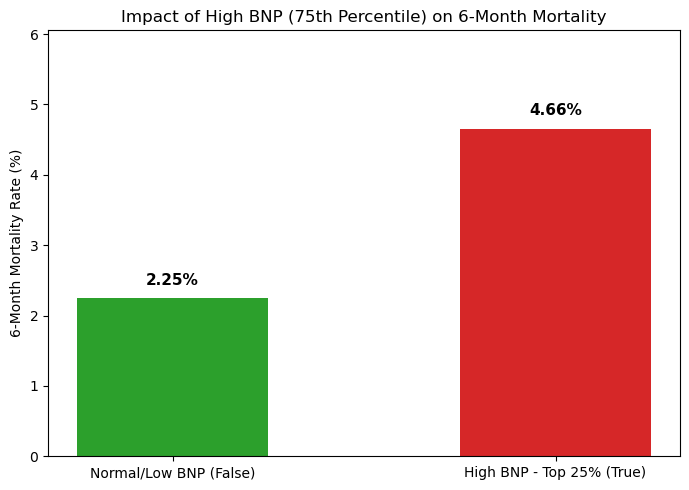

In [10]:
# Calculate the 75th percentile limit and group flag
limit = df["brain_natriuretic_peptide"].quantile(0.75)
df["high_bnp"] = df["brain_natriuretic_peptide"] >= limit

# Aggregate data
result = df.groupby("high_bnp").agg(
    Patients=("patient_id", "count"), Mortality=("death_within_6_months", "mean")
)
result["Mortality"] *= 100

print("Dataset top-25% BNP limit:", limit)
display(result)

# Create the enhanced bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(
    ["Normal/Low BNP (False)", "High BNP - Top 25% (True)"],
    result["Mortality"],
    color=["#2ca02c", "#d62728"],
    width=0.5,
)

# Set Y-axis limits and labels
plt.ylim(0, max(result["Mortality"]) * 1.3)
plt.ylabel("6-Month Mortality Rate (%)")
plt.title("Impact of High BNP (75th Percentile) on 6-Month Mortality")

# Add exact data labels on top of each bar
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.,
      height + 0.15,
      f"{height:.2f}%",
      ha="center",
      va="bottom",
      fontsize=11,
      fontweight="bold",
  )

plt.tight_layout()
plt.show()

**Analysis:**
High BNP levels double the 6-month mortality risk, making these patients a top priority for close monitoring


**Q10. How can we effectively stratify patients presenting with high troponin values to identify those who need urgent medical attention?**

**Reason:**
Troponin is another cardiac measurement. We identify the dataset's upper 25% and compare outcomes. This avoids inventing a medical treatment threshold while still letting us explore whether relatively high values are associated with poorer outcomes.


75th percentile: 0.1


high_troponin
False    1.102204
True     4.554455
Name: death_within_6_months, dtype: float64

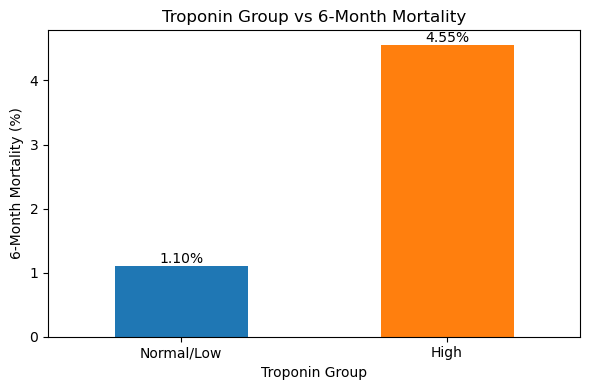

In [11]:
import matplotlib.pyplot as plt

# Calculate the 75th percentile limit for high-sensitivity troponin
limit = df["high_sensitivity_troponin"].quantile(0.75)
df["high_troponin"] = df["high_sensitivity_troponin"] >= limit

# Calculate 6-month mortality percentage by group
result = df.groupby("high_troponin")["death_within_6_months"].mean() * 100

print("75th percentile:", limit)
display(result)

# Create the clean bar chart with proper Troponin labels
ax = result.plot(
    kind="bar",
    figsize=(6,4),
    color=["#1F77B4","#FF7F0E"]
)

ax.set_xticklabels(["Normal/Low","High"], rotation=0)

plt.ylabel("6-Month Mortality (%)")
plt.xlabel("Troponin Group")
plt.title("Troponin Group vs 6-Month Mortality")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Analysis:** High troponin levels significantly increase 6-month mortality risk, making these patients a priority for close clinical review and follow-up.


**Q11. Which patients with higher creatinine should receive closer monitoring?**

**Reason:**
Creatinine provides information related to kidney function. We use the upper 25% of the dataset as an exploratory group and compare creatinine distributions between patients who survived and those who died within six months.


Top 25% limit: 122.7
Patients: 497
6-month mortality (%): 5.633802816901409


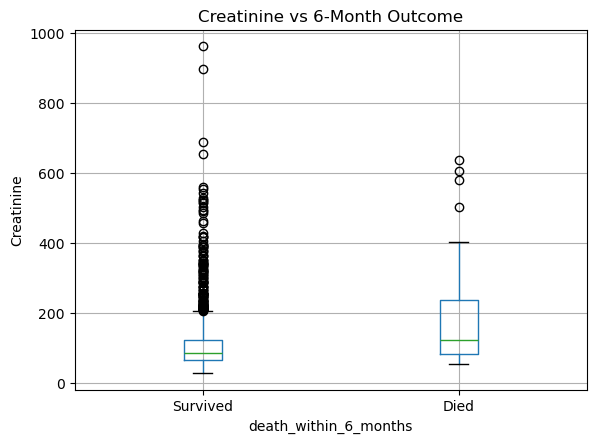

In [12]:
limit = df["creatinine_enzymatic_method"].quantile(0.75)
high = df[df["creatinine_enzymatic_method"] >= limit]

print("Top 25% limit:", limit)
print("Patients:", len(high))
print("6-month mortality (%):",
      high["death_within_6_months"].mean() * 100)

df.boxplot(
    column="creatinine_enzymatic_method",
    by="death_within_6_months"
)
plt.xticks([1, 2], ["Survived", "Died"])
plt.ylabel("Creatinine")
plt.title("Creatinine vs 6-Month Outcome")
plt.suptitle("")
plt.show()


**Analysis**
497 patients had creatinine ≥122.7, with a 5.63% 6-month mortality rate, suggesting an association between higher creatinine and 6-month mortality.


**Q12. Which patients with higher urea should receive closer monitoring?**

**Reason:**
Urea is another laboratory measurement related to patient condition. We compare patients in the highest 25% of urea values with the overall outcome data.



Top 25% limit: 11.5
Patients: 505
6-month readmission (%): 46.33663366336634
6-month mortality (%): 5.742574257425743


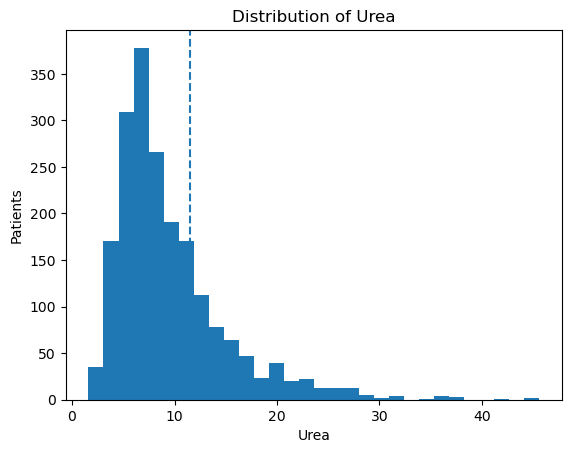

In [13]:
limit = df["urea"].quantile(0.75)
high = df[df["urea"] >= limit]

print("Top 25% limit:", limit)
print("Patients:", len(high))
print("6-month readmission (%):",
      high["re_admission_within_6_months"].mean() * 100)
print("6-month mortality (%):",
      high["death_within_6_months"].mean() * 100)

plt.hist(df["urea"].dropna(), bins=30)
plt.axvline(limit, linestyle="--")
plt.xlabel("Urea")
plt.ylabel("Patients")
plt.title("Distribution of Urea")
plt.show()


**Analysis**
The top 25% of patients with urea levels of 11.5 or higher included 505 patients. Among them, 46.34% were readmitted and 5.74% died within 6 months. These results suggest that higher urea levels may be associated with readmission and mortality.


**Q13. How significantly does elevated blood lactate (top 25% quartile, mmol/L) correlate with 6-month mortality, and should this threshold be used to prioritize clinical review?"**

**Reason:**
Lactate can provide information about patient condition, but missing data must be considered. We first count available values, then compare the upper 25% with mortality.


Available lactate values: 993
Top 25% limit: 2.5
Patients in high group: 256
6-month mortality (%): 7.421875


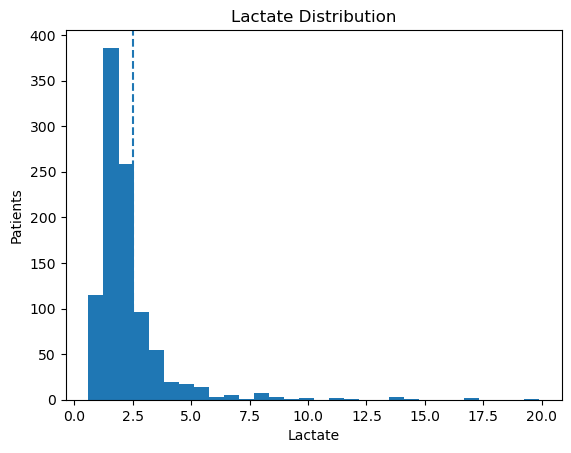

In [14]:
limit = df["lactate"].quantile(0.75)
high = df[df["lactate"] >= limit]

print("Available lactate values:", df["lactate"].notna().sum())
print("Top 25% limit:", limit)
print("Patients in high group:", len(high))
print("6-month mortality (%):",
      high["death_within_6_months"].mean() * 100)

plt.hist(df["lactate"].dropna(), bins=30)
plt.axvline(limit, linestyle="--")
plt.xlabel("Lactate")
plt.ylabel("Patients")
plt.title("Lactate Distribution")
plt.show()


**Analysis**
Patients with blood lactate levels at or above 2.5 mmol/L represent the top 25% highest-risk subgroup ($n = 256$), exhibiting a 7.42% 6-month mortality rate. While elevated lactate highlights a vulnerable cohort requiring closer monitoring.


**Q14. How does blood sodium status (Hyponatremia vs. Hypernatremia) impact 6-month patient mortality?**

**Reason:** Blood sodium is a powerful metabolic flag in cardiovascular medicine.We segment patients using established clinical guidelines i.e. Hyponatremia (<135 mEq/L), Normal (135–145 mEq/L), and Hypernatremia (>145 mEq/L).


           sodium_group  Patients  Mortality_Rate
0  Hypernatremia (>145)        61        3.278689
1   Hyponatremia (<135)       387        4.909561
3      Normal (135-145)      1549        2.259522


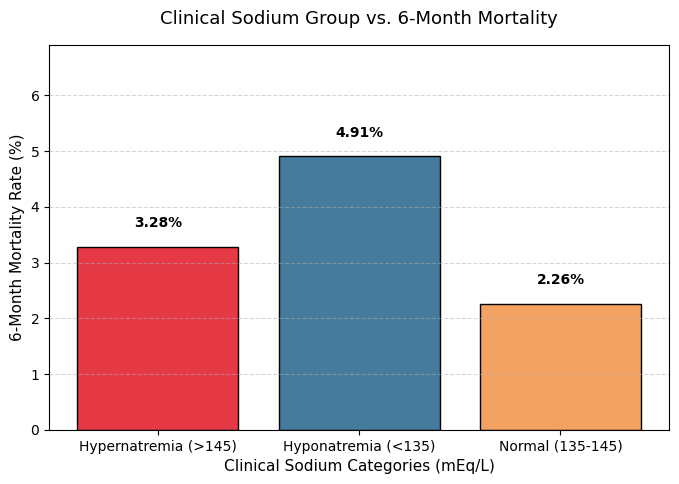

In [15]:
# Define the clinical boundaries mapping function
def classify_sodium_clinical(val):
    if pd.isna(val):
        return "Missing"
    elif val < 135:
        return "Hyponatremia (<135)"
    elif val > 145:
        return "Hypernatremia (>145)"
    else:
        return "Normal (135-145)"


#Apply the classification to the dataset
df["sodium_group"] = df["sodium"].apply(classify_sodium_clinical)

#Aggregate patient volume and mortality rates
sodium_analysis = (
    df.groupby("sodium_group", observed=False)
    .agg(
        Patients=("patient_id", "count"),
        Mortality_Rate=("death_within_6_months", "mean"),
    )
    .reset_index()
)

# Convert mortality rate to percentage
sodium_analysis["Mortality_Rate"] *= 100
sodium_analysis = sodium_analysis[sodium_analysis["sodium_group"] != "Missing"]
print(sodium_analysis)

#Visualization (Grouped Bar Chart)
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sodium_analysis["sodium_group"],
    sodium_analysis["Mortality_Rate"],
    color=["#e63946", "#457b9d", "#f4a261"],
    edgecolor="black",
)
#Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("6-Month Mortality Rate (%)", fontsize=11)
plt.xlabel("Clinical Sodium Categories (mEq/L)", fontsize=11)
plt.title("Clinical Sodium Group vs. 6-Month Mortality", fontsize=13, pad=15)
plt.ylim(0, max(sodium_analysis["Mortality_Rate"]) + 2)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

**Analysis:** Low blood sodium (under 135 mEq/L) is a medical warning sign that significantly increases a patient's risk of death. Because of this, hospitals should automatically place any heart failure patient with low sodium onto a strict monitoring plan with rules on daily fluid limits.

**Q15. Which patients with unusual potassium values should be reviewed?**

**Reason:**
Potassium can also contain unusual values. We use the IQR method to identify statistical outliers and compare the distribution with patient outcomes.


Statistical limits: 2.3000000000000003 5.5
potassium_outlier
False    1946
True       62
Name: count, dtype: int64


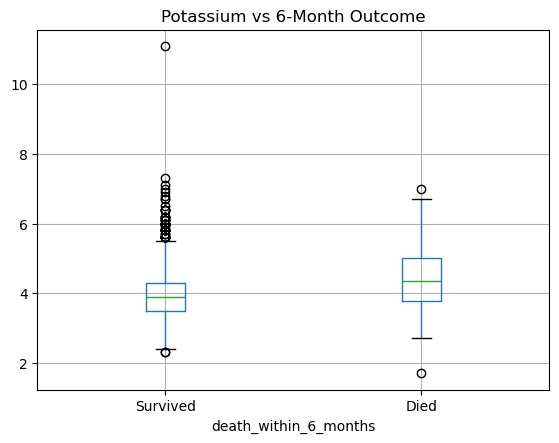

In [16]:
q1 = df["potassium"].quantile(0.25)
q3 = df["potassium"].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

df["potassium_outlier"] = (
    (df["potassium"] < low) | (df["potassium"] > high)
)

print("Statistical limits:", low, high)
print(df["potassium_outlier"].value_counts())

df.boxplot(column="potassium", by="death_within_6_months")
plt.xticks([1, 2], ["Survived", "Died"])
plt.title("Potassium vs 6-Month Outcome")
plt.suptitle("")
plt.show()


**Analysis**
This identifies unusual potassium measurements that should be investigated before they are used in predictive modeling.


**Q16. What helps us figure out which patients with irregular vital signs are at the highest risk?**

**Reason:**
Pulse, respiration, and blood pressure give a quick view of patient condition. Very unusual values can represent either important patient conditions or data-quality problems, so we should examine their distributions before using them for recommendations.


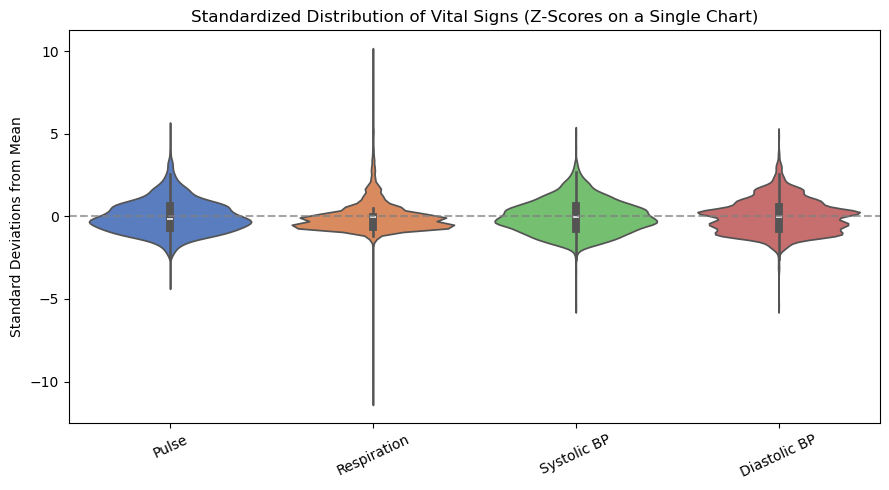

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

vitals = [
    "pulse",
    "respiration",
    "systolic_blood_pressure",
    "diastolic_blood_pressure",
]

# Standardize the vital signs (Z-score: mean = 0, std = 1) for a fair single-chart comparison
df_standardized = (df[vitals] - df[vitals].mean()) / df[vitals].std()

plt.figure(figsize=(9, 5))
sns.violinplot(data=df_standardized, palette="muted", inner="box")

plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title(
    "Standardized Distribution of Vital Signs (Z-Scores on a Single Chart)"
)
plt.ylabel("Standard Deviations from Mean")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "Pulse",
        "Respiration",
        "Systolic BP",
        "Diastolic BP",
    ],
    rotation=25,
)
plt.tight_layout()
plt.show()


**Analysis** Investigate extreme outliers—particularly respiration readings stretching past ±5 to 10 standard deviations—to separate genuine respiratory distress from electronic charting errors.

**Q17. Which specific patients receiving oxygen should be flagged for a quicker follow-up?**


**Reason:**
Oxygen use can be compared with patient outcomes. If almost everyone receives oxygen, however, oxygen use alone may not separate low- and high-risk patients well.

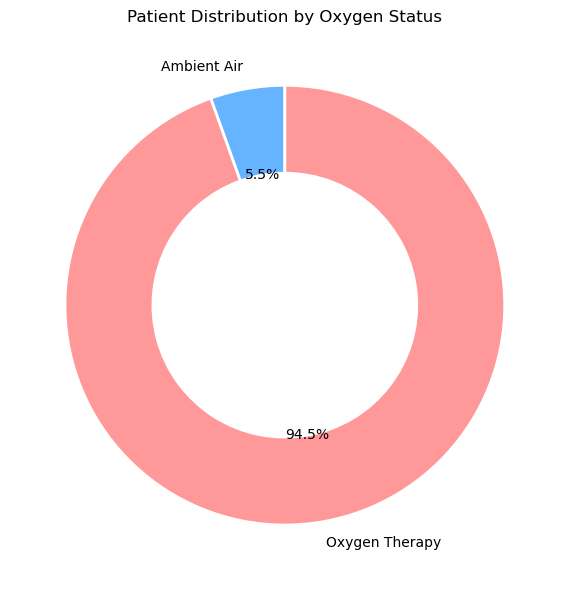

In [18]:

# Aggregate the data
result = df.groupby("oxygen_inhalation").agg(
    Patients=("patient_id", "count"), Mortality=("death_within_6_months", "mean")
)

# Set up the figure for a Donut Chart (Circle Chart)
plt.figure(figsize=(6, 6))

# Create the pie with a circle cutout in the center (donut style)
plt.pie(
    result["Patients"],
    labels=result.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"],
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)

plt.title("Patient Distribution by Oxygen Status")
plt.tight_layout()
plt.show()

**Analysis** The chart highlights a severe imbalance in patient volume, with a dominant 94.5% belonging to the primary category and only 5.5% making up the secondary group.Knowing that only a small fraction of patients fall into this category helps the care team prepare the right amount of specialized equipment and attention without wasting resources where they aren't needed.


**Q18. Which patients requiring respiratory support should receive the closest monitoring?**

**Reason**
Respiratory support may identify a smaller and more complex patient group. We compare support categories with mortality, while paying close attention to small sample sizes.

,Patients,Mortality
respiratory_support,,
IMV,25,32.0
NIMV,17,0.0


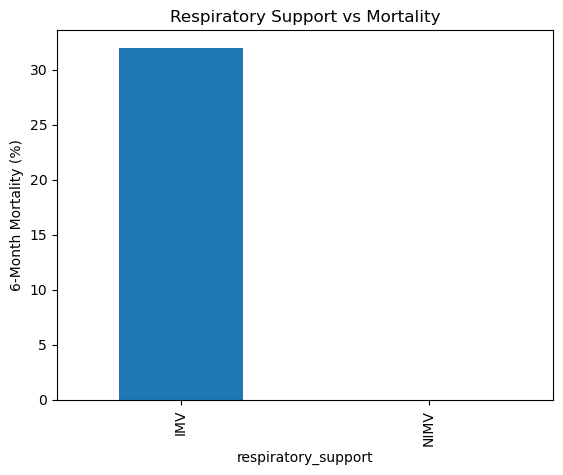

In [19]:
result = df.groupby("respiratory_support").agg(
    Patients=("patient_id", "count"),
    Mortality=("death_within_6_months", "mean")
)
result["Mortality"] *= 100
display(result)

result["Mortality"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.title("Respiratory Support vs Mortality")
plt.show()


**Analysis**
If a respiratory-support group shows poor outcomes, it may be useful for prioritization, but very small groups should not be generalized.


**Q19. Is a higher medication count associated with increased 6-month readmission?**

**Reason:**
Medication count gives us a simple view of treatment complexity. We calculate the average and the 75th percentile, then examine outcomes among patients in the upper medication-count group.



Average medications: 7.65
75th percentile: 9.0
Top 25% starts at: 9.0
Patients in higher medication-count group: 722
6-month readmission (%): 41.97


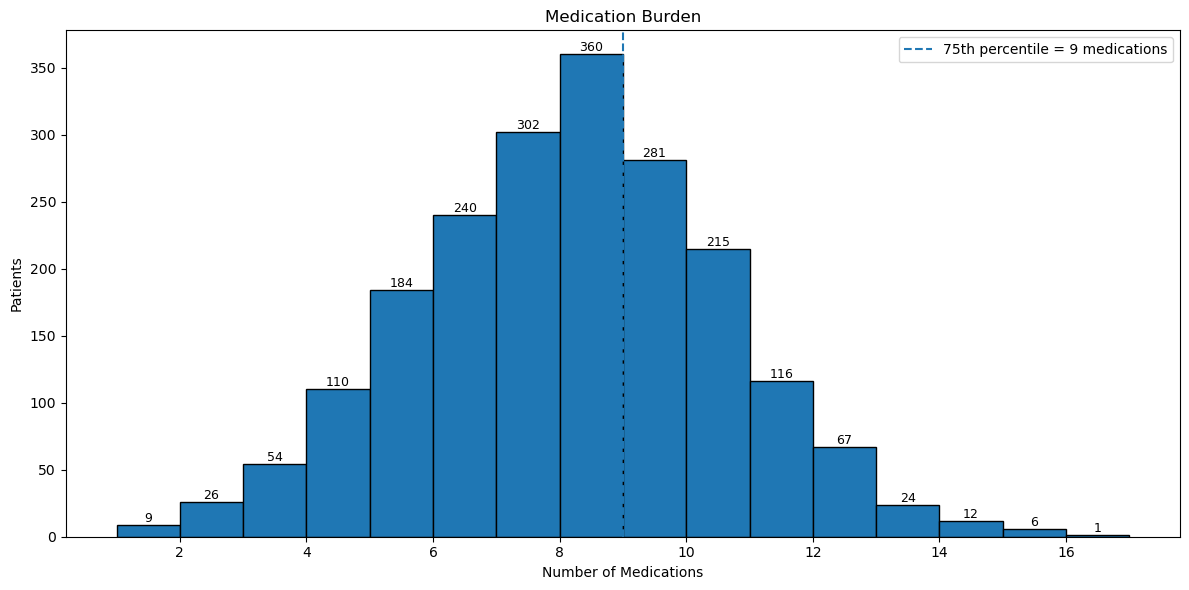

In [20]:
# Calculate the 75th percentile
limit = df["drug_count"].quantile(0.75)

# Select patients in the higher medication-count group
high = df[df["drug_count"] >= limit]

# Print summary
print("Average medications:", round(df["drug_count"].mean(), 2))
print("75th percentile:", limit)
print("Top 25% starts at:", limit)
print("Patients in higher medication-count group:", len(high))

print(
    "6-month readmission (%):",
    round(high["re_admission_within_6_months"].mean() * 100, 2)
)

# Create histogram
plt.figure(figsize=(12, 6))

counts, bins, patches = plt.hist(
    df["drug_count"].dropna(),
    bins=range(1, 18),
    edgecolor="black"
)

# Add patient count above each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            str(int(count)),
            ha="center",
            va="bottom",
            fontsize=9
        )

# Show 75th percentile line
plt.axvline(
    limit,
    linestyle="--",
    label=f"75th percentile = {limit:.0f} medications"
)

plt.xlabel("Number of Medications")
plt.ylabel("Patients")
plt.title("Medication Burden")
plt.legend()

plt.tight_layout()
plt.show()


**Analysis**
The average medication count in the dataset is approximately 7.65 medications per patient. Patients taking 9 or more medications fall into the higher medication-count group, which includes 722 patients. Among these patients, 41.97% experienced readmission within 6 months.


**Q20. Does having both high medication burden and high comorbidity burden relate to higher 6-month readmission?**

**Reason:**
We use the 75th percentile of medication count and CCI score as data-based thresholds. Patients at or above both thresholds are considered the high medication + high comorbidity group(high complex group). We then measure how many patients fall into this group and examine their 6-month readmission rate.


75th percentile - Medication count: 9.0
75th percentile - CCI score: 2.0
Patients with both high medication burden and high CCI: 432
6-month readmission (%): 43.98


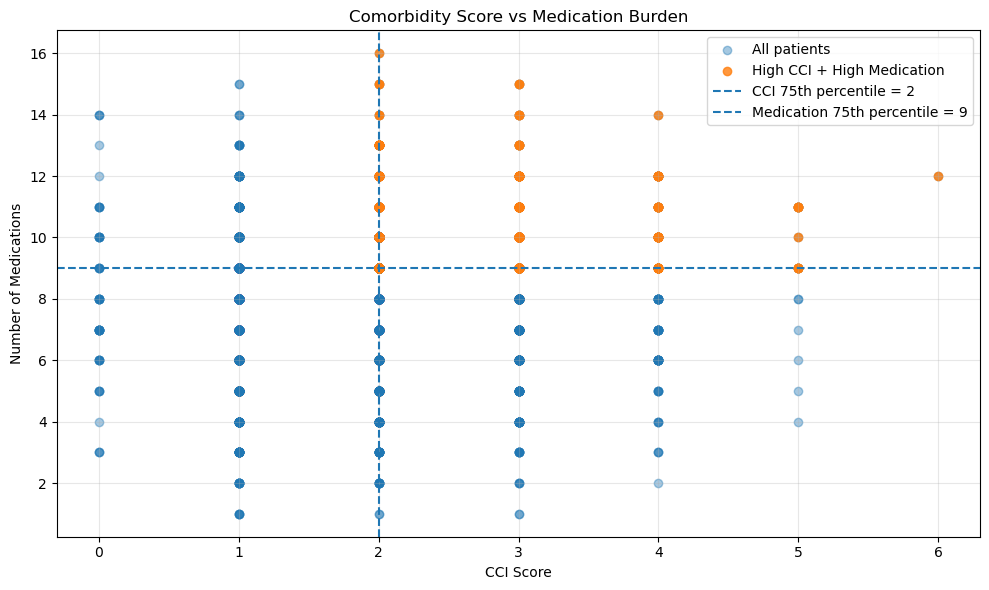

,Patients,Readmission,Mortality
Other patients,1576,36.99,2.98
High medication + High CCI,432,43.98,2.31


In [21]:
drug_limit = df["drug_count"].quantile(0.75)
cci_limit = df["cci_score"].quantile(0.75)

print("75th percentile - Medication count:", drug_limit)
print("75th percentile - CCI score:", cci_limit)

complex_group = df[
    (df["drug_count"] >= drug_limit) &
    (df["cci_score"] >= cci_limit)
]

print("Patients with both high medication burden and high CCI:",
      len(complex_group))

print(
    "6-month readmission (%):",
    round(
        complex_group["re_admission_within_6_months"].mean() * 100,
        2
    )
)


plt.figure(figsize=(10, 6))

# All patients
plt.scatter(
    df["cci_score"],
    df["drug_count"],
    alpha=0.4,
    label="All patients"
)

# Patients with high CCI AND high medication count
plt.scatter(
    complex_group["cci_score"],
    complex_group["drug_count"],
    alpha=0.8,
    label="High CCI + High Medication"
)

# CCI 75th percentile
plt.axvline(
    cci_limit,
    linestyle="--",
    label=f"CCI 75th percentile = {cci_limit:.0f}"
)

# Medication 75th percentile
plt.axhline(
    drug_limit,
    linestyle="--",
    label=f"Medication 75th percentile = {drug_limit:.0f}"
)

plt.xlabel("CCI Score")
plt.ylabel("Number of Medications")
plt.title("Comorbidity Score vs Medication Burden")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

df["high_medication"] = df["drug_count"] >= drug_limit
df["high_cci"] = df["cci_score"] >= cci_limit

df["high_complexity"] = (
    df["high_medication"] &
    df["high_cci"]
)

comparison = df.groupby("high_complexity").agg(
    Patients=("patient_id", "count"),
    Readmission=("re_admission_within_6_months", "mean"),
    Mortality=("death_within_6_months", "mean")
)

comparison[["Readmission", "Mortality"]] *= 100

comparison.index = [
    "Other patients",
    "High medication + High CCI"
]

display(comparison.round(2))

**Analysis**
The high medication + high CCI group had a higher observed 6-month readmission rate at 43.98%  than the other patients 36.99% in this dataset.


**Q21. How does 28-day readmission vary across patient risk characteristics?**

**Reason:**
We first identify the number and percentage of patients readmitted within 28 days. We then compare readmitted and non-readmitted patients across medication burden, comorbidity burden, cardiac severity, kidney disease, respiratory failure, and other available characteristics. This helps identify patient groups that are more frequently represented among 28-day readmissions.


28-day readmissions: 140
28-day readmission rate (%): 6.97


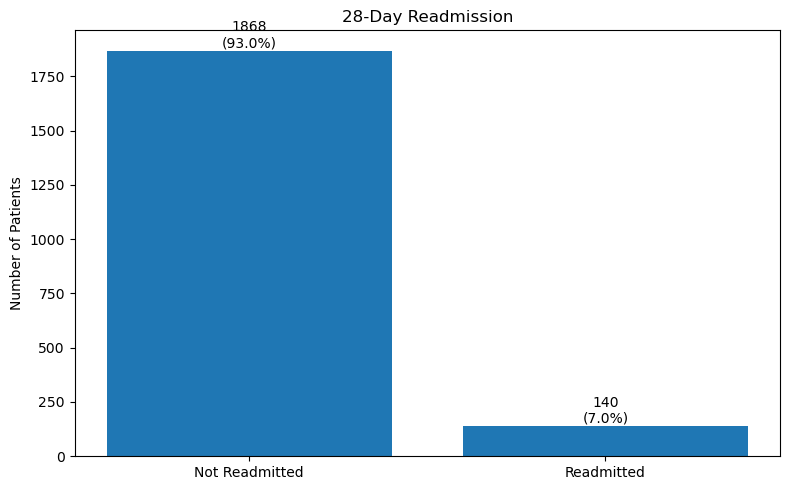

In [22]:

# Count and rate
count = df["re_admission_within_28_days"].sum()
rate = df["re_admission_within_28_days"].mean() * 100

print("28-day readmissions:", int(count))
print("28-day readmission rate (%):", round(rate, 2))

# Patient counts
readmission_counts = (
    df["re_admission_within_28_days"]
    .value_counts()
    .sort_index()
)

labels = ["Not Readmitted", "Readmitted"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, readmission_counts.values)

# Add patient count and percentage
for i, bar in enumerate(bars):
    patient_count = int(readmission_counts.values[i])
    percentage = patient_count / len(df) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{patient_count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_ylabel("Number of Patients")
ax.set_title("28-Day Readmission")
plt.tight_layout()
plt.show()


,Factor,Patients,28-Day Readmissions,28-Day Readmission Rate (%)
6,Diabetes,466,47,10.09
2,CKD,474,45,9.49
5,COPD,233,18,7.73
1,High CCI,1177,86,7.31
0,High Medication Burden,722,45,6.23
3,Type II Respiratory Failure,114,7,6.14
7,Low Ejection Fraction,163,9,5.52
4,Acute Renal Failure,7,0,0.00


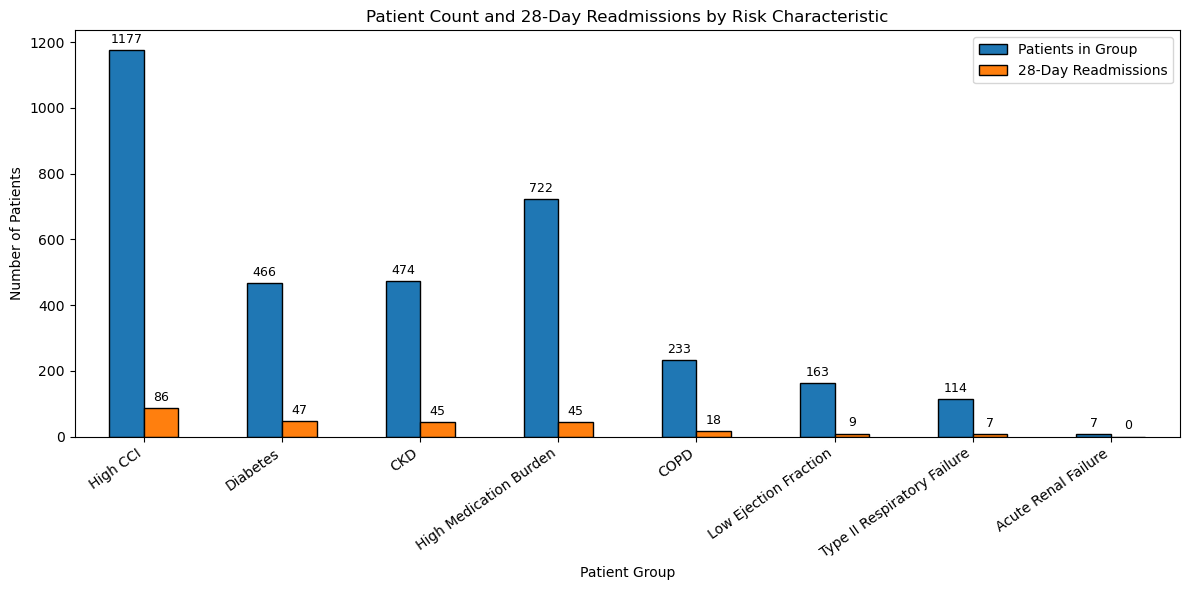

In [23]:
# Make a copy so we don't accidentally modify the original dataset
analysis_df = df.copy()

# 75th percentile thresholds
drug_limit = analysis_df["drug_count"].quantile(0.75)
cci_limit = analysis_df["cci_score"].quantile(0.75)

ef_limit = analysis_df["ejection_fraction"].quantile(0.25)

# Create analysis groups
analysis_df["High_Medication_Burden"] = (
    analysis_df["drug_count"] >= drug_limit
)

analysis_df["High_CCI"] = (
    analysis_df["cci_score"] >= cci_limit
)

analysis_df["CKD"] = (
    analysis_df["moderate_to_severe_chronic_kidney_disease"] == 1
)

analysis_df["Type_II_Respiratory_Failure"] = (
    analysis_df["type_2_respiratory_failure_Binary"] == 1
)

analysis_df["Acute_Renal_Failure"] = (
    analysis_df["acute_renal_failure"] == 1
)

analysis_df["COPD"] = (
    analysis_df["chronic_obstructive_pulmonary_disease"] == 1
)

analysis_df["Diabetes"] = (
    analysis_df["diabetes"] == 1
)

analysis_df["Low_Ejection_Fraction"] = (
    analysis_df["ejection_fraction"] <= ef_limit
)
factors = {
    "High Medication Burden": "High_Medication_Burden",
    "High CCI": "High_CCI",
    "CKD": "CKD",
    "Type II Respiratory Failure": "Type_II_Respiratory_Failure",
    "Acute Renal Failure": "Acute_Renal_Failure",
    "COPD": "COPD",
    "Diabetes": "Diabetes",
    "Low Ejection Fraction": "Low_Ejection_Fraction"
}

results = []

for factor_name, column in factors.items():

    group = analysis_df[analysis_df[column] == True]

    patients = len(group)

    readmissions = group[
        "re_admission_within_28_days"
    ].sum()

    readmission_rate = (
        group["re_admission_within_28_days"].mean() * 100
        if patients > 0
        else 0
    )

    results.append({
        "Factor": factor_name,
        "Patients": patients,
        "28-Day Readmissions": int(readmissions),
        "28-Day Readmission Rate (%)": readmission_rate
    })

factor_results = pd.DataFrame(results)

factor_results = factor_results.sort_values(
    "28-Day Readmission Rate (%)",
    ascending=False
)

display(
    factor_results.round(2)
)

plot_data = factor_results.sort_values(
    "28-Day Readmissions",
    ascending=False
)

ax = plot_data.set_index("Factor")[
    ["Patients", "28-Day Readmissions"]
].plot(
    kind="bar",
    figsize=(12, 6),
    edgecolor="black"
)

# Add numbers on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.xlabel("Patient Group")
plt.ylabel("Number of Patients")
plt.title("Patient Count and 28-Day Readmissions by Risk Characteristic")
plt.xticks(rotation=35, ha="right")

plt.legend(
    ["Patients in Group", "28-Day Readmissions"]
)

plt.tight_layout()
plt.show()

**Analysis**
28-day readmission was 7%, with high CCI, diabetes, CKD, and high medication burden showing the highest numbers of readmissions.


**Q22. How does 3 month readmission vary across patient risk characteristics?**

**Reason:**
Some patients return later rather than within the first month. Measuring 3-month readmission shows whether the follow-up problem grows over time.


3-month readmissions: 498
3-month readmission rate (%): 24.8


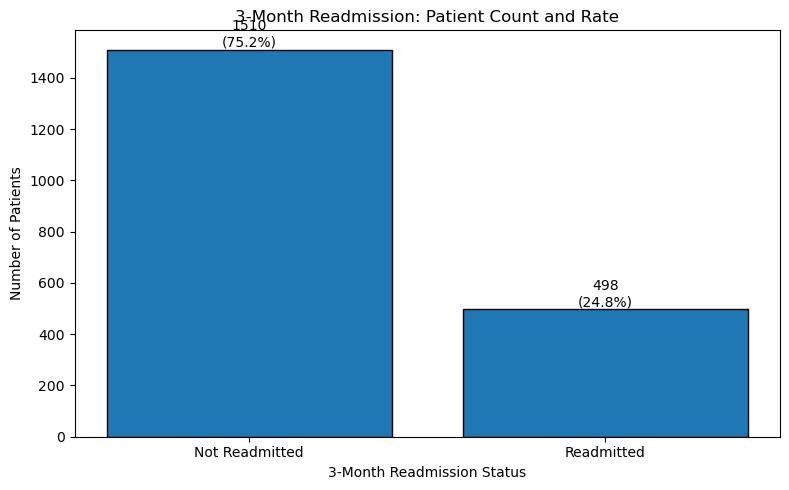

In [24]:
count = df["re_admission_within_3_months"].sum()
rate = df["re_admission_within_3_months"].mean() * 100

print("3-month readmissions:", int(count))
print("3-month readmission rate (%):", round(rate, 2))

readmission_counts = (
    df["re_admission_within_3_months"]
    .value_counts()
    .sort_index()
)

labels = ["Not Readmitted", "Readmitted"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    readmission_counts.values,
    edgecolor="black"
)

for bar, value in zip(bars, readmission_counts.values):
    percentage = value / readmission_counts.sum() * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("3-Month Readmission Status")
plt.ylabel("Number of Patients")
plt.title("3-Month Readmission: Patient Count and Rate")

plt.tight_layout()
plt.show()


In [25]:
# Make a copy
analysis_df = df.copy()

# 75th percentile thresholds
drug_limit = analysis_df["drug_count"].quantile(0.75)
cci_limit = analysis_df["cci_score"].quantile(0.75)

# 25th percentile for lower ejection fraction
ef_limit = analysis_df["ejection_fraction"].quantile(0.25)

# Create analysis groups
analysis_df["High_Medication_Burden"] = (
    analysis_df["drug_count"] >= drug_limit
)

analysis_df["High_CCI"] = (
    analysis_df["cci_score"] >= cci_limit
)

analysis_df["CKD"] = (
    analysis_df["moderate_to_severe_chronic_kidney_disease"] == 1
)

analysis_df["Type_II_Respiratory_Failure"] = (
    analysis_df["type_2_respiratory_failure_Binary"] == 1
)

analysis_df["Acute_Renal_Failure"] = (
    analysis_df["acute_renal_failure"] == 1
)

analysis_df["COPD"] = (
    analysis_df["chronic_obstructive_pulmonary_disease"] == 1
)

analysis_df["Diabetes"] = (
    analysis_df["diabetes"] == 1
)

analysis_df["Low_Ejection_Fraction"] = (
    analysis_df["ejection_fraction"] <= ef_limit
)

factors = {
    "High Medication Burden": "High_Medication_Burden",
    "High CCI": "High_CCI",
    "CKD": "CKD",
    "Type II Respiratory Failure": "Type_II_Respiratory_Failure",
    "Acute Renal Failure": "Acute_Renal_Failure",
    "COPD": "COPD",
    "Diabetes": "Diabetes",
    "Low Ejection Fraction": "Low_Ejection_Fraction"
}

results = []

for factor_name, column in factors.items():

    group = analysis_df[analysis_df[column] == True]

    patients = len(group)

    readmissions = group[
        "re_admission_within_3_months"
    ].sum()

    readmission_rate = (
        group["re_admission_within_3_months"].mean() * 100
        if patients > 0
        else 0
    )

    results.append({
        "Factor": factor_name,
        "Patients": patients,
        "3-Month Readmissions": int(readmissions),
        "3-Month Readmission Rate (%)": readmission_rate
    })

factor_results_3m = pd.DataFrame(results)

factor_results_3m = factor_results_3m.sort_values(
    "3-Month Readmission Rate (%)",
    ascending=False
)

display(factor_results_3m.round(2))

,Factor,Patients,3-Month Readmissions,3-Month Readmission Rate (%)
6,Diabetes,466,143,30.69
2,CKD,474,145,30.59
0,High Medication Burden,722,197,27.29
5,COPD,233,63,27.04
1,High CCI,1177,311,26.42
7,Low Ejection Fraction,163,41,25.15
3,Type II Respiratory Failure,114,25,21.93
4,Acute Renal Failure,7,0,0.00


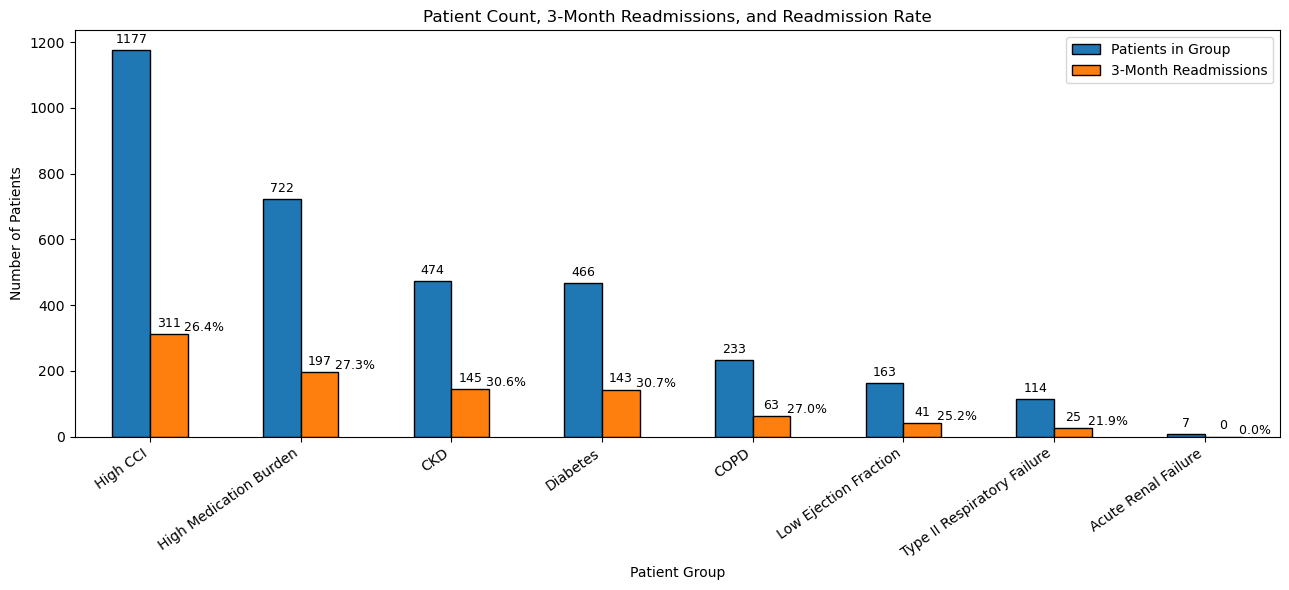

In [26]:
plot_data = factor_results_3m.sort_values(
    "3-Month Readmissions",
    ascending=False
)

ax = plot_data.set_index("Factor")[
    ["Patients", "3-Month Readmissions"]
].plot(
    kind="bar",
    figsize=(13, 6),
    edgecolor="black"
)

# Add numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

# Add readmission rate
for i, rate in enumerate(
    plot_data["3-Month Readmission Rate (%)"]
):
    ax.text(
        i + 0.20,
        plot_data.iloc[i]["3-Month Readmissions"],
        f" {rate:.1f}%",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Patient Group")
plt.ylabel("Number of Patients")
plt.title(
    "Patient Count, 3-Month Readmissions, and Readmission Rate"
)

plt.xticks(rotation=35, ha="right")

plt.legend(
    ["Patients in Group", "3-Month Readmissions"]
)

plt.tight_layout()
plt.show()

**Analysis**
3-month readmission was 24.8%, with high CCI, diabetes, CKD, and high medication burden showing the highest numbers of readmissions. No much difference from 28-day readmission factor influence, see higher number.



**Q23: How does 6 month readmission vary across patient risk characteristics?**

**Reason:**
Some patients return later rather than within the first month. Measuring 6-month readmission shows whether the follow-up problem grows over time.



6-month readmissions: 773
6-month readmission rate (%): 38.5


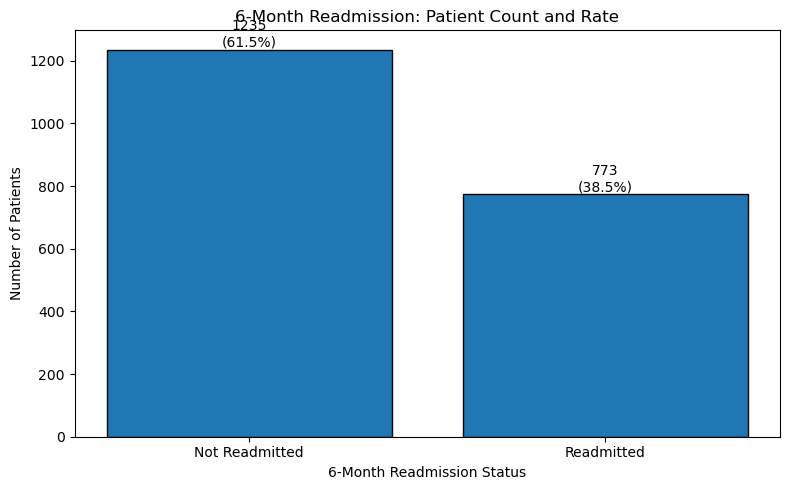

In [27]:
count = df["re_admission_within_6_months"].sum()
rate = df["re_admission_within_6_months"].mean() * 100

print("6-month readmissions:", int(count))
print("6-month readmission rate (%):", round(rate, 2))

readmission_counts = (
    df["re_admission_within_6_months"]
    .value_counts()
    .sort_index()
)

labels = ["Not Readmitted", "Readmitted"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    readmission_counts.values,
    edgecolor="black"
)

for bar, value in zip(bars, readmission_counts.values):
    percentage = value / readmission_counts.sum() * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("6-Month Readmission Status")
plt.ylabel("Number of Patients")
plt.title("6-Month Readmission: Patient Count and Rate")

plt.tight_layout()
plt.show()


In [28]:
# Make a copy
analysis_df = df.copy()

# 75th percentile thresholds
drug_limit = analysis_df["drug_count"].quantile(0.75)
cci_limit = analysis_df["cci_score"].quantile(0.75)

# 25th percentile for lower ejection fraction
ef_limit = analysis_df["ejection_fraction"].quantile(0.25)

# Create analysis groups
analysis_df["High_Medication_Burden"] = (
    analysis_df["drug_count"] >= drug_limit
)

analysis_df["High_CCI"] = (
    analysis_df["cci_score"] >= cci_limit
)

analysis_df["CKD"] = (
    analysis_df["moderate_to_severe_chronic_kidney_disease"] == 1
)

analysis_df["Type_II_Respiratory_Failure"] = (
    analysis_df["type_2_respiratory_failure_Binary"] == 1
)

analysis_df["Acute_Renal_Failure"] = (
    analysis_df["acute_renal_failure"] == 1
)

analysis_df["COPD"] = (
    analysis_df["chronic_obstructive_pulmonary_disease"] == 1
)

analysis_df["Diabetes"] = (
    analysis_df["diabetes"] == 1
)

analysis_df["Low_Ejection_Fraction"] = (
    analysis_df["ejection_fraction"] <= ef_limit
)

factors = {
    "High Medication Burden": "High_Medication_Burden",
    "High CCI": "High_CCI",
    "CKD": "CKD",
    "Type II Respiratory Failure": "Type_II_Respiratory_Failure",
    "Acute Renal Failure": "Acute_Renal_Failure",
    "COPD": "COPD",
    "Diabetes": "Diabetes",
    "Low Ejection Fraction": "Low_Ejection_Fraction"
}

results = []

for factor_name, column in factors.items():

    group = analysis_df[analysis_df[column] == True]

    patients = len(group)

    readmissions = group[
        "re_admission_within_6_months"
    ].sum()

    readmission_rate = (
        group["re_admission_within_6_months"].mean() * 100
        if patients > 0
        else 0
    )

    results.append({
        "Factor": factor_name,
        "Patients": patients,
        "6-Month Readmissions": int(readmissions),
        "6-Month Readmission Rate (%)": readmission_rate
    })

factor_results_6m = pd.DataFrame(results)

factor_results_6m = factor_results_6m.sort_values(
    "6-Month Readmission Rate (%)",
    ascending=False
)

display(factor_results_6m.round(2))

,Factor,Patients,6-Month Readmissions,6-Month Readmission Rate (%)
2,CKD,474,219,46.20
6,Diabetes,466,213,45.71
0,High Medication Burden,722,303,41.97
7,Low Ejection Fraction,163,67,41.10
1,High CCI,1177,477,40.53
5,COPD,233,89,38.20
3,Type II Respiratory Failure,114,39,34.21
4,Acute Renal Failure,7,2,28.57


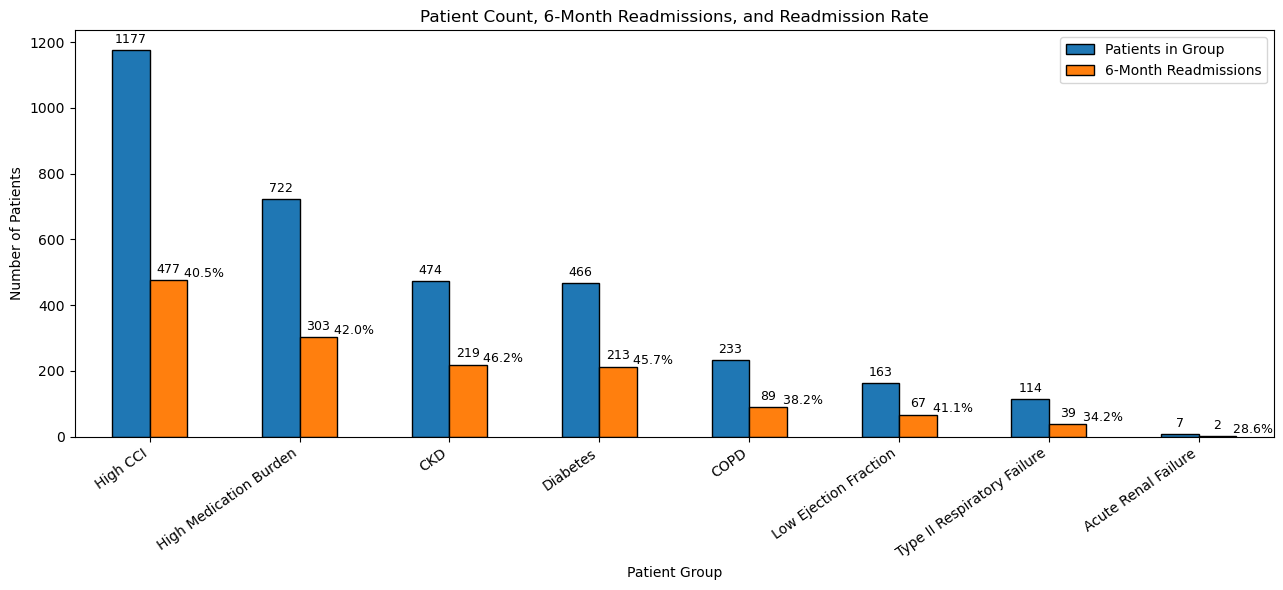

In [29]:
plot_data = factor_results_6m.sort_values(
    "6-Month Readmissions",
    ascending=False
)

ax = plot_data.set_index("Factor")[
    ["Patients", "6-Month Readmissions"]
].plot(
    kind="bar",
    figsize=(13, 6),
    edgecolor="black"
)

# Add patient/readmission counts above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

# Add readmission rate
for i, rate in enumerate(
    plot_data["6-Month Readmission Rate (%)"]
):
    ax.text(
        i + 0.20,
        plot_data.iloc[i]["6-Month Readmissions"],
        f" {rate:.1f}%",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Patient Group")
plt.ylabel("Number of Patients")
plt.title(
    "Patient Count, 6-Month Readmissions, and Readmission Rate"
)

plt.xticks(rotation=35, ha="right")

plt.legend(
    ["Patients in Group", "6-Month Readmissions"]
)

plt.tight_layout()
plt.show()

**Analysis**
3-month readmission was 24.8%, with high CCI, diabetes, CKD, and high medication burden showing the highest numbers of readmissions. No much difference from 28-day readmission factor influence, see higher number.


**Q24. Which patients should be prioritized to reduce emergency department returns?**

**Reason:**
An emergency department return is another sign that a patient may need additional post-discharge support. We calculate how common ED return is within six months.


6-month ED returns: 775
6-month ED return rate (%): 38.61


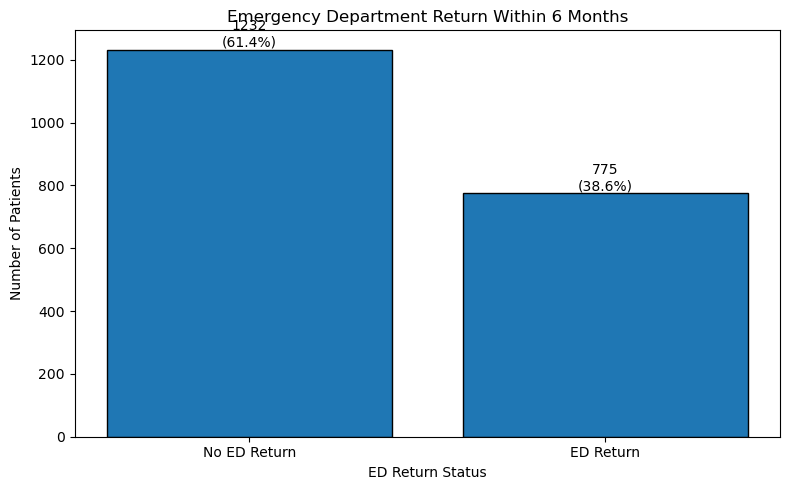

In [30]:
col = "return_to_emergency_department_within_6_months"

count = df[col].sum()
rate = df[col].mean() * 100

print("6-month ED returns:", int(count))
print("6-month ED return rate (%):", round(rate, 2))

ed_counts = df[col].value_counts().sort_index()

labels = ["No ED Return", "ED Return"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    ed_counts.values,
    edgecolor="black"
)

for bar, value in zip(bars, ed_counts.values):
    percentage = value / ed_counts.sum() * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("ED Return Status")
plt.ylabel("Number of Patients")
plt.title("Emergency Department Return Within 6 Months")

plt.tight_layout()
plt.show()


In [31]:
# Make a copy
analysis_df = df.copy()

# 75th percentile thresholds
drug_limit = analysis_df["drug_count"].quantile(0.75)
cci_limit = analysis_df["cci_score"].quantile(0.75)

# 25th percentile for lower ejection fraction
ef_limit = analysis_df["ejection_fraction"].quantile(0.25)

# Create analysis groups
analysis_df["High_Medication_Burden"] = (
    analysis_df["drug_count"] >= drug_limit
)

analysis_df["High_CCI"] = (
    analysis_df["cci_score"] >= cci_limit
)

analysis_df["CKD"] = (
    analysis_df["moderate_to_severe_chronic_kidney_disease"] == 1
)

analysis_df["Type_II_Respiratory_Failure"] = (
    analysis_df["type_2_respiratory_failure_Binary"] == 1
)

analysis_df["Acute_Renal_Failure"] = (
    analysis_df["acute_renal_failure"] == 1
)

analysis_df["COPD"] = (
    analysis_df["chronic_obstructive_pulmonary_disease"] == 1
)

analysis_df["Diabetes"] = (
    analysis_df["diabetes"] == 1
)

analysis_df["Low_Ejection_Fraction"] = (
    analysis_df["ejection_fraction"] <= ef_limit
)

factors = {
    "High Medication Burden": "High_Medication_Burden",
    "High CCI": "High_CCI",
    "CKD": "CKD",
    "Type II Respiratory Failure": "Type_II_Respiratory_Failure",
    "Acute Renal Failure": "Acute_Renal_Failure",
    "COPD": "COPD",
    "Diabetes": "Diabetes",
    "Low Ejection Fraction": "Low_Ejection_Fraction"
}

results = []

for factor_name, column in factors.items():

    group = analysis_df[analysis_df[column] == True]

    patients = len(group)

    ed_returns = group[
        "return_to_emergency_department_within_6_months"
    ].sum()

    ed_return_rate = (
        group[
            "return_to_emergency_department_within_6_months"
        ].mean() * 100
        if patients > 0
        else 0
    )

    results.append({
        "Factor": factor_name,
        "Patients": patients,
        "6-Month ED Returns": int(ed_returns),
        "ED Return Rate (%)": ed_return_rate
    })

factor_results_ed = pd.DataFrame(results)

factor_results_ed = factor_results_ed.sort_values(
    "ED Return Rate (%)",
    ascending=False
)

display(factor_results_ed.round(2))

,Factor,Patients,6-Month ED Returns,ED Return Rate (%)
2,CKD,474,217,45.78
6,Diabetes,466,212,45.49
0,High Medication Burden,722,302,41.83
7,Low Ejection Fraction,163,67,41.10
1,High CCI,1177,477,40.56
5,COPD,233,87,37.34
3,Type II Respiratory Failure,114,39,34.21
4,Acute Renal Failure,7,2,28.57


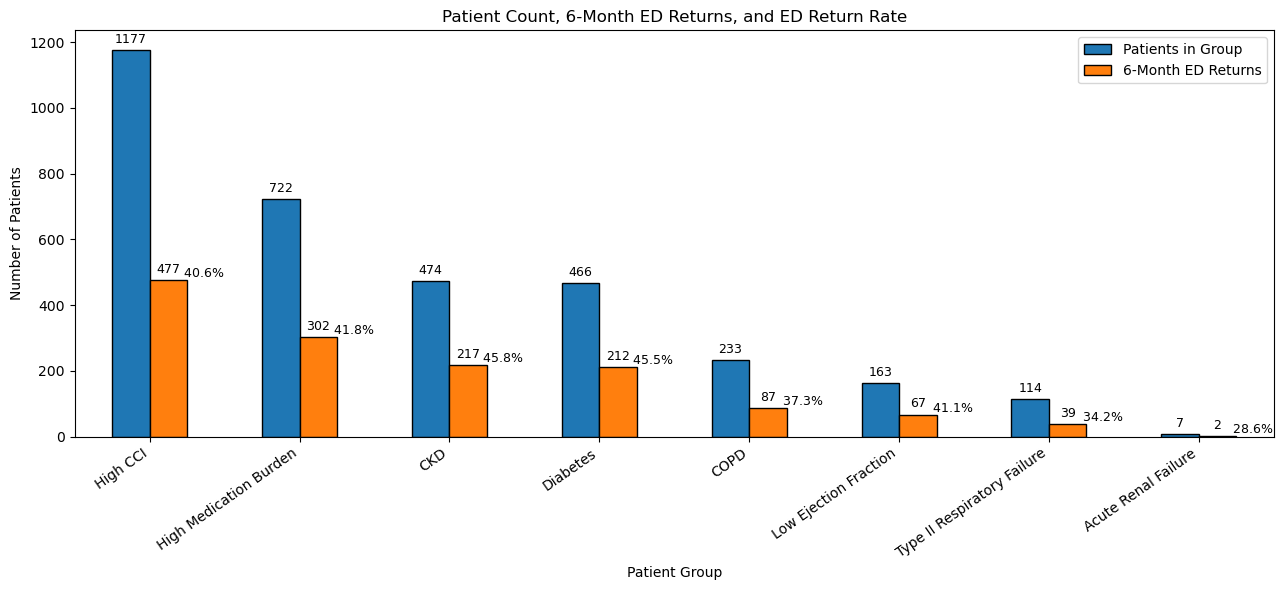

In [32]:
plot_data = factor_results_ed.sort_values(
    "6-Month ED Returns",
    ascending=False
)

ax = plot_data.set_index("Factor")[
    ["Patients", "6-Month ED Returns"]
].plot(
    kind="bar",
    figsize=(13, 6),
    edgecolor="black"
)

# Add patient and ED return counts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

# Add ED return rate
for i, rate in enumerate(
    plot_data["ED Return Rate (%)"]
):
    ax.text(
        i + 0.20,
        plot_data.iloc[i]["6-Month ED Returns"],
        f" {rate:.1f}%",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Patient Group")
plt.ylabel("Number of Patients")

plt.title(
    "Patient Count, 6-Month ED Returns, and ED Return Rate"
)

plt.xticks(rotation=35, ha="right")

plt.legend(
    ["Patients in Group", "6-Month ED Returns"]
)

plt.tight_layout()
plt.show()

**Analysis**
ED readmission was 38.61, with high CCI, diabetes, CKD, and high medication burden showing the highest numbers of readmissions. No much difference from 28-day readmission factor, 3-month, 6-month influence and see higher readmission numbers.

**Q25. Which patients with longer hospital stays should receive closer follow-up?**

**Reason:**
Hospital stay length may reflect a more complicated hospitalization. We compare the stay measure with 28-day readmission. Before interpreting the result, we must confirm exactly what the dataset's discharge-day field represents.


count    2008.000000
mean        9.420817
std         8.030256
min         1.000000
25%         6.000000
50%         8.000000
75%        10.000000
max       123.000000
Name: discharge_day, dtype: float64


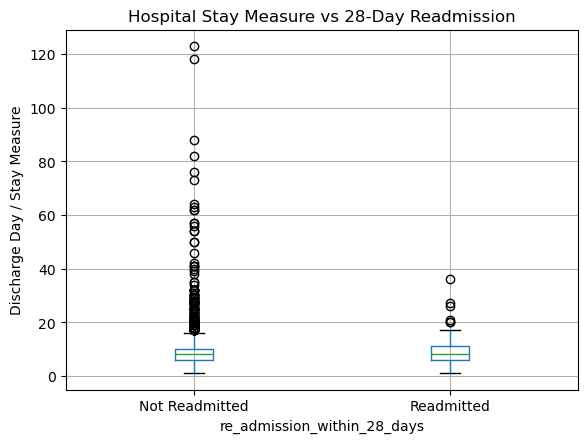

In [33]:
print(df["discharge_day"].describe())

df.boxplot(
    column="discharge_day",
    by="re_admission_within_28_days"
)
plt.xticks([1, 2], ["Not Readmitted", "Readmitted"])
plt.ylabel("Discharge Day / Stay Measure")
plt.title("Hospital Stay Measure vs 28-Day Readmission")
plt.suptitle("")
plt.show()


**Analysis**
If readmitted patients show a different stay pattern, hospital stay may help identify patients needing closer discharge follow-up. Confirm the meaning of `discharge_day` before treating it as exact length of stay.


**Q26. Which patients should receive closer monitoring for 28-day mortality risk?**

**Reason:**
Short-term mortality is a serious outcome. We first calculate how many patients died within 28 days and the percentage of the dataset. If deaths are rare, predictive modeling must account for class imbalance.


28-day deaths: 37
28-day mortality rate (%): 1.8426294820717133


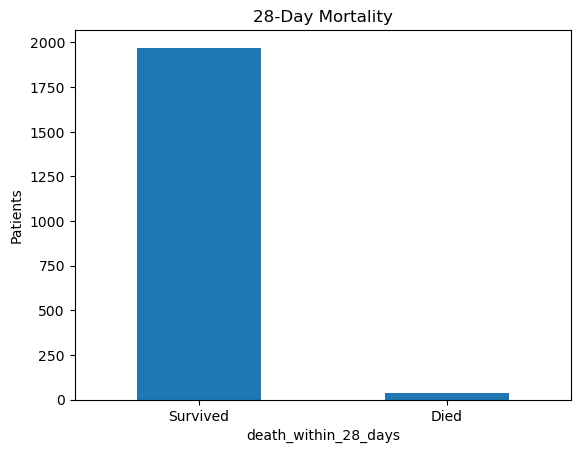

In [34]:
deaths = df["death_within_28_days"].sum()
rate = df["death_within_28_days"].mean() * 100

print("28-day deaths:", deaths)
print("28-day mortality rate (%):", rate)

df["death_within_28_days"].value_counts().sort_index().plot(
    kind="bar"
)
plt.xticks([0, 1], ["Survived", "Died"], rotation=0)
plt.ylabel("Patients")
plt.title("28-Day Mortality")
plt.show()


**Analysis**
This establishes the short-term mortality burden and shows whether mortality is too rare to model naively. Multiple patient characteristics should be considered together.


**Q27. Which patients should receive continued monitoring for 3-month mortality?**

**Reason**
Mortality may continue after the first month. Measuring the 3-month outcome helps us understand whether longer monitoring should be considered for higher-risk groups.

3-month deaths: 42
3-month mortality rate (%): 2.091633466135458


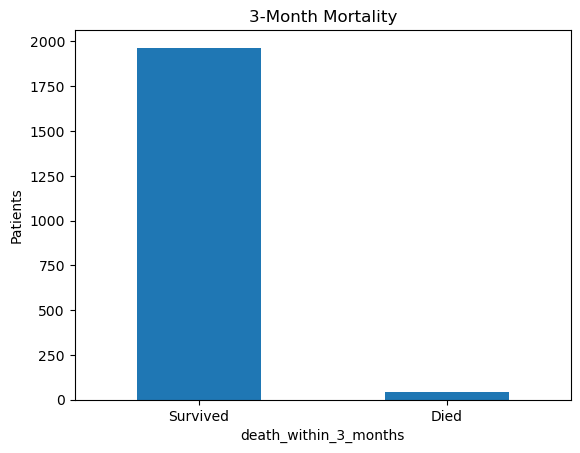

In [35]:
deaths = df["death_within_3_months"].sum()
rate = df["death_within_3_months"].mean() * 100

print("3-month deaths:", deaths)
print("3-month mortality rate (%):", rate)

df["death_within_3_months"].value_counts().sort_index().plot(
    kind="bar"
)
plt.xticks([0, 1], ["Survived", "Died"], rotation=0)
plt.ylabel("Patients")
plt.title("3-Month Mortality")
plt.show()


**Analysis**
This shows how mortality changes after the first 28 days and supports investigating which patient groups may need continued monitoring.


**Q28. Which patients should receive longer-term monitoring for 6-month mortality?**

**Reason**
Six-month mortality provides a longer-term patient outcome. Comparing mortality across 28 days, 3 months, and 6 months helps us see how the outcome changes over time.

6-month deaths: 57
6-month mortality rate (%): 2.838645418326693


28 Days     1.842629
3 Months    2.091633
6 Months    2.838645
dtype: float64

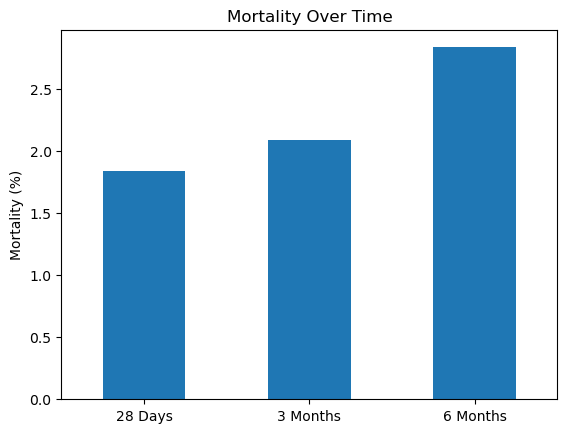

In [36]:
deaths = df["death_within_6_months"].sum()
rate = df["death_within_6_months"].mean() * 100

print("6-month deaths:", deaths)
print("6-month mortality rate (%):", rate)

mortality = pd.Series({
    "28 Days": df["death_within_28_days"].mean() * 100,
    "3 Months": df["death_within_3_months"].mean() * 100,
    "6 Months": df["death_within_6_months"].mean() * 100
})

display(mortality)

mortality.plot(kind="bar")
plt.ylabel("Mortality (%)")
plt.title("Mortality Over Time")
plt.xticks(rotation=0)
plt.show()


**Analysis**
This shows whether mortality continues to rise over time and supports studying longer-term risk rather than only the earliest outcome.

**Q29. How can we identify low, medium, and high-priority patient groups?**

**Reason**
One measurement alone may not be enough. We can build an exploratory score by combining several signals such as severe NYHA class, lower GCS, higher CCI score, and the upper BNP group. This is not a validated medical risk score; it is a way to test whether combined information separates outcomes better.

,Patients,Readmission,Mortality
priority_group,,,
Low,497,32.796781,1.408451
Medium,1335,40.299625,2.471910
High,176,40.909091,9.659091


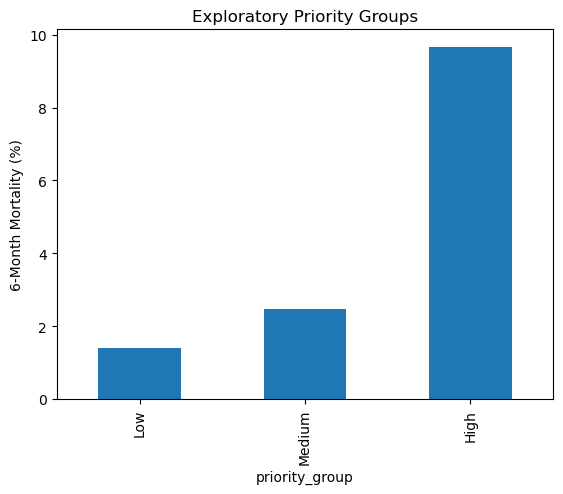

In [37]:
df["priority_score"] = 0

df.loc[df["nyha_class"] == 4, "priority_score"] += 1
df.loc[df["glasgow_coma_scale"] < 15, "priority_score"] += 1

df.loc[
    df["cci_score"] >= df["cci_score"].quantile(0.75),
    "priority_score"
] += 1

df.loc[
    df["brain_natriuretic_peptide"] >=
    df["brain_natriuretic_peptide"].quantile(0.75),
    "priority_score"
] += 1

df["priority_group"] = pd.cut(
    df["priority_score"],
    bins=[-1, 0, 2, 4],
    labels=["Low", "Medium", "High"]
)

result = df.groupby("priority_group", observed=True).agg(
    Patients=("patient_id", "count"),
    Readmission=("re_admission_within_6_months", "mean"),
    Mortality=("death_within_6_months", "mean")
)

result[["Readmission", "Mortality"]] *= 100
display(result)

result["Mortality"].plot(kind="bar")
plt.ylabel("6-Month Mortality (%)")
plt.title("Exploratory Priority Groups")
plt.show()


**Analysis**
If poor outcomes rise from low to medium to high groups, combining several characteristics may be more useful than looking at one variable alone. The score would still need proper validation before real-world use.

**Q30. What monitoring and follow-up should be prioritized for patients at higher risk of readmission or mortality?**

**Reason:**
This final question brings the analysis together. We examine how severity, responsiveness, comorbidity burden, medication count, and selected laboratory values relate to six-month readmission and mortality. The goal is to decide which variables deserve the most attention in the next predictive stage.

,re_admission_within_6_months,death_within_6_months
nyha_class,0.106149,0.059491
killip_grade,-0.001651,0.195096
glasgow_coma_scale,0.051629,-0.356875
cci_score,0.080723,0.018376
drug_count,0.088209,-0.049814
brain_natriuretic_peptide,0.032646,0.101036
creatinine_enzymatic_method,0.054023,0.152936
urea,0.062101,0.174402
lactate,0.030969,0.191845


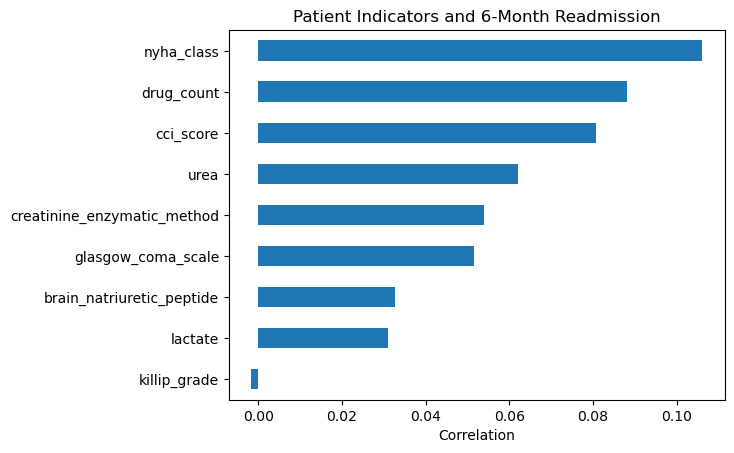

In [38]:
features = [
    "nyha_class",
    "killip_grade",
    "glasgow_coma_scale",
    "cci_score",
    "drug_count",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "urea",
    "lactate"
]

analysis_cols = features + [
    "re_admission_within_6_months",
    "death_within_6_months"
]

correlation = df[analysis_cols].corr()

outcome_corr = correlation[
    ["re_admission_within_6_months",
     "death_within_6_months"]
].drop(
    ["re_admission_within_6_months",
     "death_within_6_months"]
)

display(outcome_corr)

outcome_corr["re_admission_within_6_months"].sort_values().plot(
    kind="barh"
)
plt.xlabel("Correlation")
plt.title("Patient Indicators and 6-Month Readmission")
plt.show()


**Analysis**
This final analysis identifies variables that deserve deeper predictive modeling. It does not prove that changing a variable will prevent readmission or death. Instead, it helps focus future risk modeling, monitoring, and clinical review.
